<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Deep Learning and Reinforcement Learning**

## Module 1 - Introduction to Neural Networks
### Demo: Gradient Descent

## **Ringkasan**
Dalam notebook ini, kita akan menyelesaikan masalah regresi linear sederhana menggunakan metode **Gradient Descent**. 

Kita akan mempelajari:
1. Efek dari **learning rate** terhadap lintasan pencarian parameter.
2. Perbedaan antara **Stochastic Gradient Descent (SGD)** dengan versi standar (Batch Gradient Descent).
3. Efek dari pengacakan data (**shuffling**) saat menggunakan SGD.


In [1]:
# Persiapan - Mengimpor pustaka yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## **Menghasilkan Data dari Distribusi yang Diketahui**
Di bawah ini kita akan membuat data sintetis agar kita tahu jawaban "aslinya". 
Model yang akan kita gunakan adalah:

$Y = b + \theta_1 X_1 + \theta_2 X_2 + \epsilon$

Keterangan:
* $X_1$ dan $X_2$ memiliki distribusi seragam (*uniform*) pada interval $[0,10]$.
* `const` adalah vektor berisi angka 1 (mewakili suku intersep/bias).
* Kita tentukan nilai parameter asli: $b=1.5$, $\theta_1=2$, dan $\theta_2=5$.
* Kita tambahkan sedikit derau (*noise*) $\epsilon$ untuk mensimulasikan data dunia nyata.


In [2]:
np.random.seed(1234)  # Menentukan seed agar hasil random konsisten

num_obs = 100
x1 = np.random.uniform(0,10,num_obs)
x2 = np.random.uniform(0,10,num_obs)
const = np.ones(num_obs)
eps = np.random.normal(0, 0.5, num_obs)

b = 1.5
theta_1 = 2
theta_2 = 5

y = b*const + theta_1*x1 + theta_2*x2 + eps

x_mat = np.array([const, x1, x2]).T

## **Mendapatkan Jawaban "Benar" Secara Langsung**
Sebelum menggunakan Gradient Descent, kita cari dulu solusi optimal menggunakan metode statistik standar. 

Penting untuk diingat bahwa meskipun kita tahu nilai aslinya ($1.5, 2, 5$), estimasi dari data yang terbatas mungkin akan sedikit berbeda karena adanya *noise*.


### **Latihan:**
Selesaikan masalah ini dengan dua cara:
1. Menggunakan model `LinearRegression` dari scikit-learn.
2. Menggunakan aljabar matriks secara langsung melalui rumus: $\theta = (X^T X)^{-1}X^Ty$


In [3]:
### Cara 1: Menggunakan scikit-learn
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression(fit_intercept=False)
lr_model.fit(x_mat, y)

print(f"Koefisien dari sklearn: {lr_model.coef_}")

Koefisien dari sklearn: [1.49004618 1.99675416 5.01156315]


In [4]:
### Cara 2: Menggunakan perhitungan matriks
theta_direct = np.linalg.inv(np.dot(x_mat.T, x_mat)).dot(x_mat.T).dot(y)
print(f"Koefisien dari rumus matriks: {theta_direct}")

Koefisien dari rumus matriks: [1.49004618 1.99675416 5.01156315]


## **Penyelesaian dengan Gradient Descent**

Untuk sebagian besar masalah numerik yang kompleks, kita tidak bisa mendapatkan solusi analitis (rumus pasti) hanya dengan pena dan kertas. Untungnya, kita bisa mendekati solusi tersebut secara bertahap menggunakan **Gradient Descent**.

Metode ini sangat penting karena Jaringan Saraf Tiruan (Neural Networks) dilatih menggunakan variasi dari Gradient Descent. Dengan memahami contoh sederhana ini, kita akan mendapatkan intuisi tentang pengaturan *learning rate* dan parameter lainnya.


### **Latihan**

Berikut adalah kode untuk melakukan **Full-Batch Gradient Descent**. Anda perlu mengisi beberapa parameter.

1. Pilih sebuah *learning rate* dan jumlah iterasi, jalankan kode, lalu lihat grafik lintasannya.
2. Cari contoh di mana *learning rate* terlalu tinggi, terlalu rendah, dan yang "pas".
3. Perhatikan plot fungsi *loss* (kerugian) pada kondisi tersebut.


In [5]:
## Parameter yang bisa Anda ubah-ubah
learning_rate = 1e-3
num_iter = 1000
theta_initial = np.array([3,3,3])

In [6]:
def gradient_descent(learning_rate, num_iter, theta_initial):
    ## Inisialisasi
    theta = theta_initial
    theta_path = np.zeros((num_iter + 1, 3))
    theta_path[0, :] = theta_initial

    loss_vec = np.zeros(num_iter)

    ## Loop Utama Gradient Descent
    for i in range(num_iter):
        y_pred = np.dot(x_mat, theta)
        loss_vec[i] = np.sum((y - y_pred)**2)
        
        # Hitung gradien: rata-rata turunan dari error kuadrat
        grad_vec = (y_pred - y).dot(x_mat) / num_obs
        
        # Perbarui theta: bergerak berlawanan arah gradien
        theta = theta - learning_rate * grad_vec
        theta_path[i+1, :] = theta
        
    return theta_path, loss_vec

In [7]:
# Fungsi untuk visualisasi
true_coef = [b, theta_1, theta_2]

def plot_ij(theta_path, i, j, ax):
    ax.plot(true_coef[i], true_coef[j], marker='p', markersize=15, label='target asli', color='#778899')
    ax.plot(theta_path[:, i], theta_path[:, j], color='k', linestyle='--', marker='^', markersize=5, markevery=num_iter//20)
    ax.plot(theta_path[0, i], theta_path[0, j], marker='d', markersize=15, label='mulai', color='#F08080')
    ax.plot(theta_path[-1, i], theta_path[-1, j], marker='o', markersize=15, label='selesai', color='#F08080')
    ax.set(xlabel='theta'+str(i), ylabel='theta'+str(j))
    ax.grid(True)
    ax.legend(loc='best')

def plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial, gdtype='Gradient Descent'):
    fig = plt.figure(figsize=(16, 12))
    title = f'{gdtype} - LR: {learning_rate} // Iter: {num_iter} // Awal: {theta_initial}'
    fig.suptitle(title, fontsize=20)
    
    ax = fig.add_subplot(2, 2, 1)
    plot_ij(theta_path, 0, 1, ax)
    
    ax = fig.add_subplot(2, 2, 2)
    plot_ij(theta_path, 0, 2, ax)
    
    ax = fig.add_subplot(2, 2, 3)
    plot_ij(theta_path, 1, 2, ax)
    
    ax = fig.add_subplot(2, 2, 4)
    ax.plot(loss_vec)
    ax.set(xlabel='Iterasi', ylabel='Squared Loss')
    ax.grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

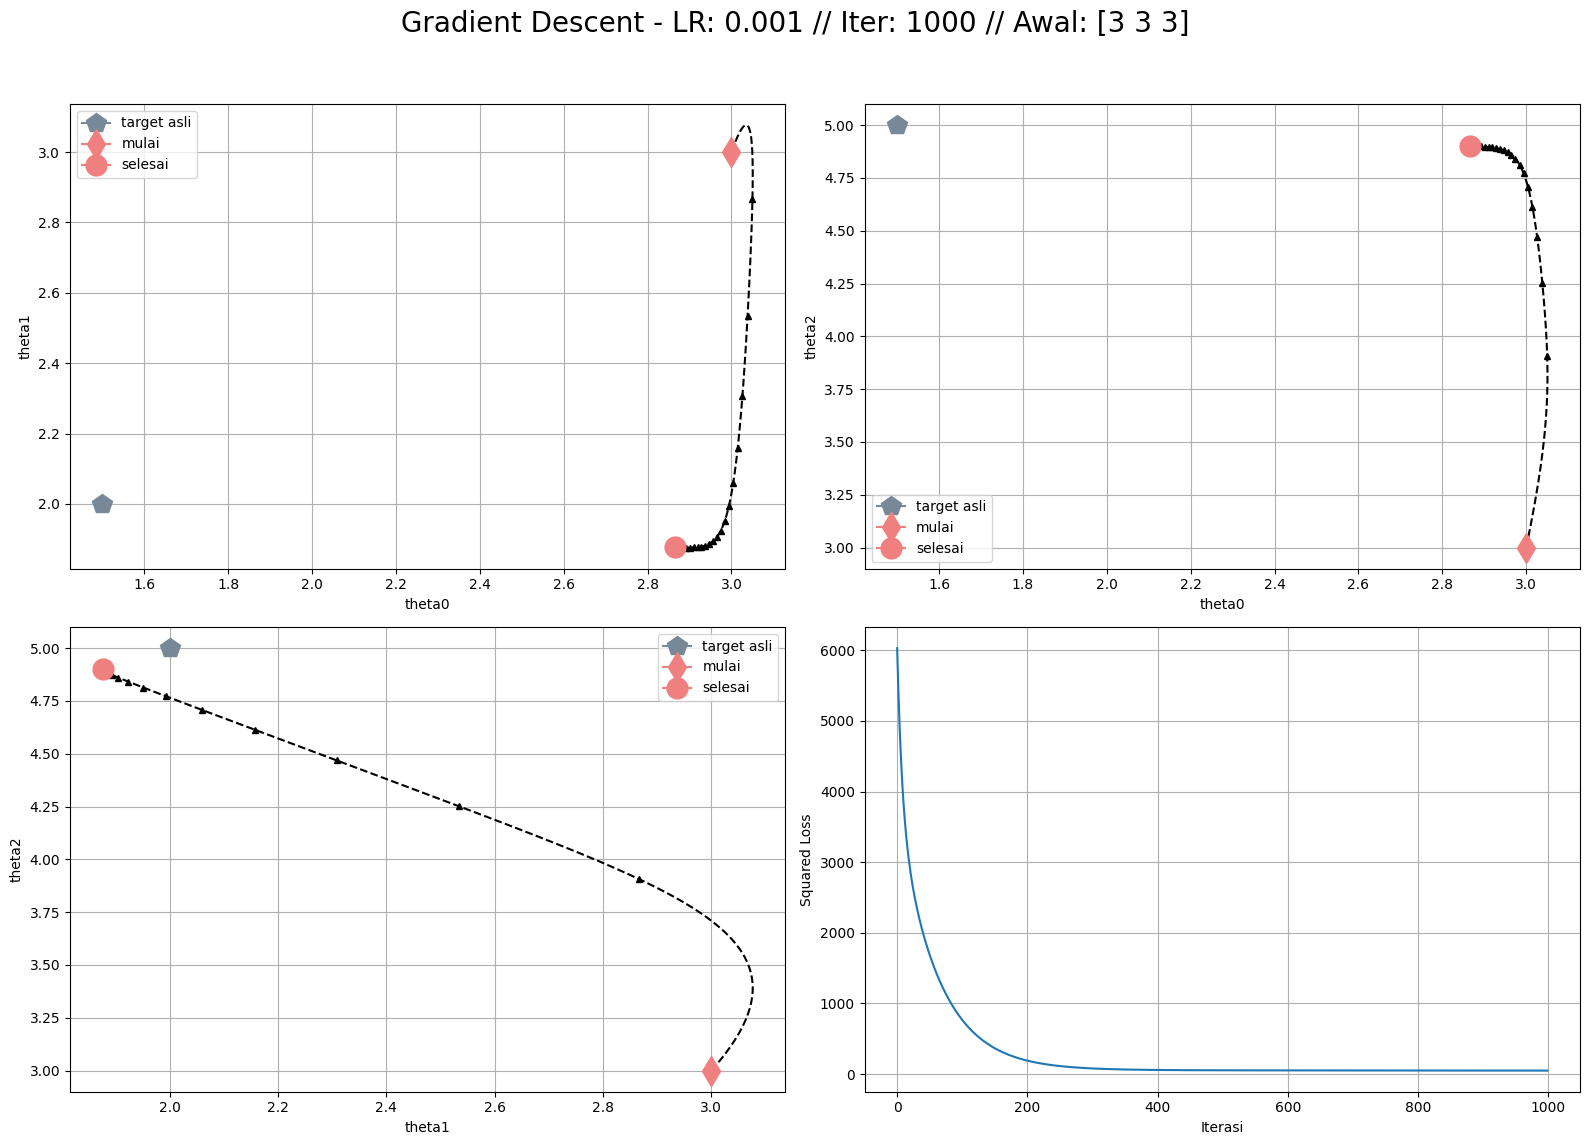

In [8]:
# Menjalankan dan menampilkan hasil
theta_path, loss_vec = gradient_descent(learning_rate, num_iter, theta_initial)
plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial)
plt.show()

## **Stochastic Gradient Descent (SGD)**
Alih-alih merata-ratakan gradien di seluruh dataset sebelum mengambil langkah (Batch), pada SGD kita akan mengambil langkah untuk **setiap satu titik data**. 

Setiap langkah mungkin akan terasa seperti "reaksi berlebihan" (zigzag), tetapi secara rata-rata langkah-langkah tersebut akan menuju ke arah yang benar.


### **Latihan**
Kode di bawah menjalankan Stochastic Gradient Descent, tetapi urutan datanya sama setiap saat.

1. Jalankan kode dan lihat grafiknya. Apa yang Anda amati?
2. **Tantangan:** Ubah kode agar data diacak (*shuffle*) di setiap iterasi. Bagaimana perbandingannya dengan lintasan tanpa pengacakan?


In [9]:
def stochastic_gradient_descent(learning_rate, num_iter, theta_initial, shuffle=False):
    theta = theta_initial
    # Kita catat posisi theta di setiap langkah kecil (j)
    theta_path = np.zeros((num_iter * num_obs + 1, 3))
    theta_path[0, :] = theta_initial
    loss_vec = np.zeros(num_iter * num_obs)

    count = 0
    for i in range(num_iter):
        indices = np.arange(num_obs)
        if shuffle:
            np.random.shuffle(indices)
            
        for j in indices:
            x_i = x_mat[j, :].reshape(1, -1)
            y_i = y[j]
            
            y_pred = np.dot(x_i, theta)
            error = y_pred - y_i
            
            # Gradien untuk SATU sampel saja
            grad_i = error * x_i.ravel()
            
            theta = theta - learning_rate * grad_i
            
            count += 1
            theta_path[count, :] = theta
            loss_vec[count-1] = error**2
            
    return theta_path, loss_vec

C:\Users\alema\AppData\Local\Temp\ipykernel_25016\2337434831.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss_vec[count-1] = error**2


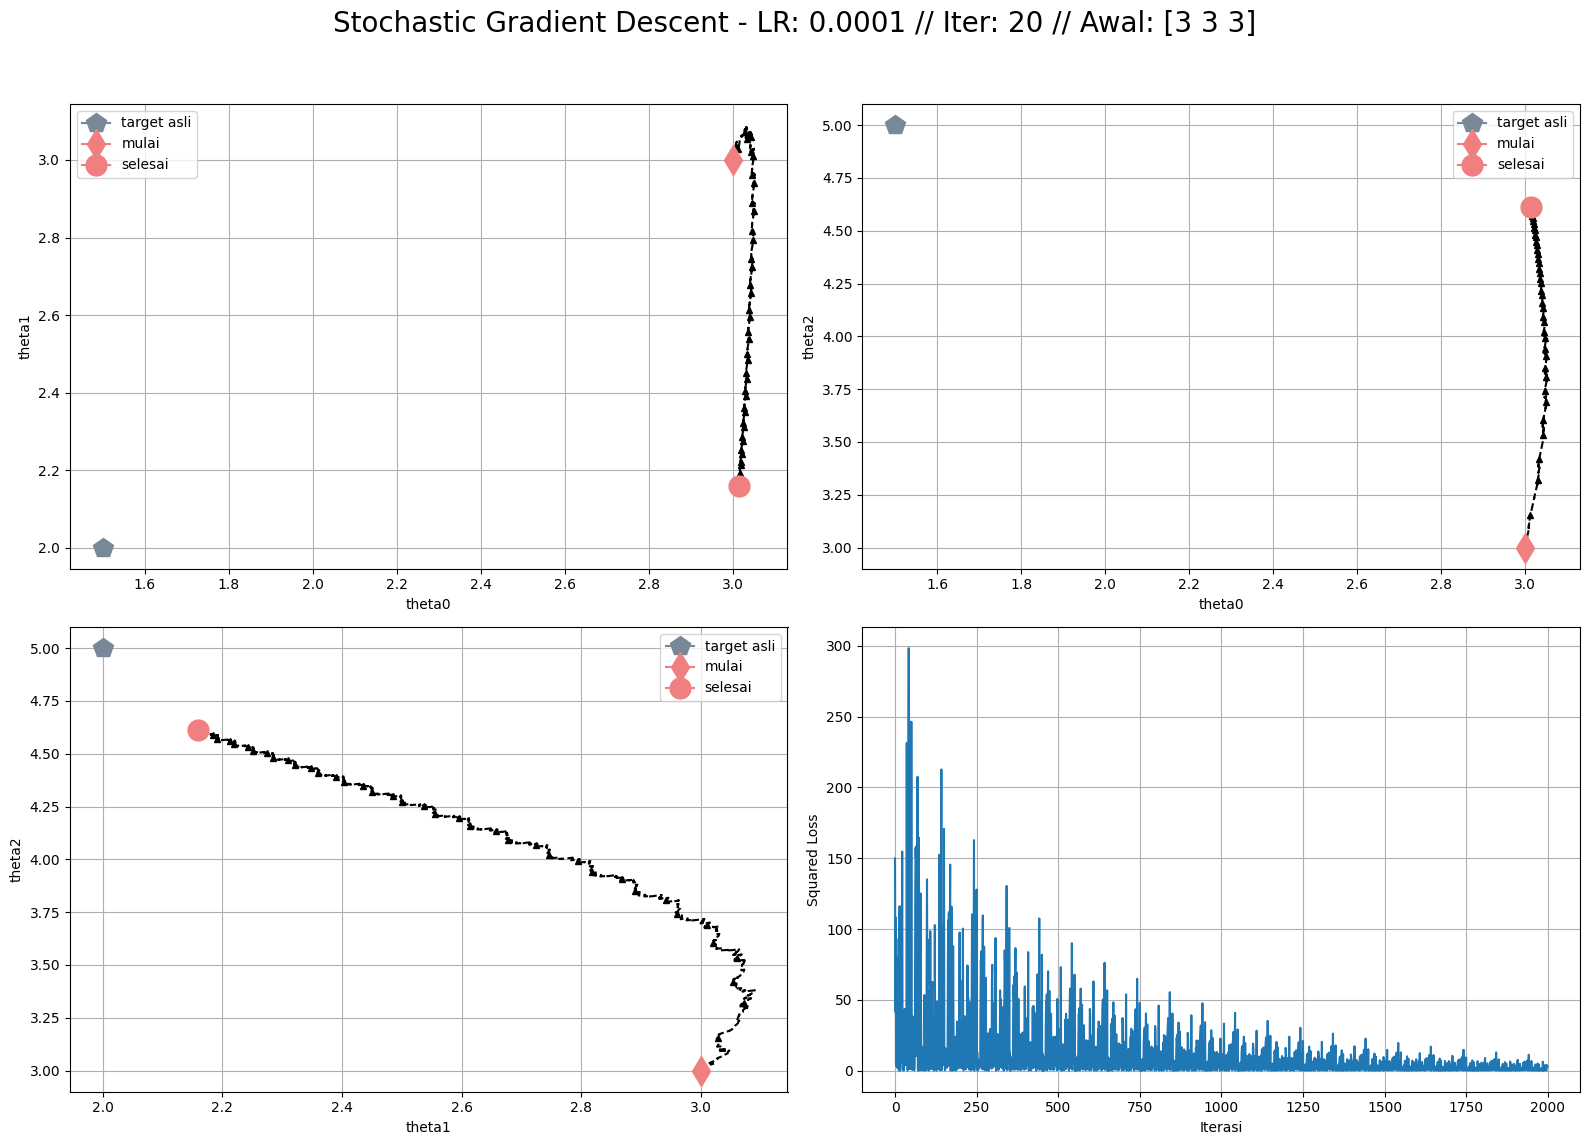

In [10]:
## Menjalankan SGD tanpa pengacakan
learning_rate_sgd = 1e-4 # SGD biasanya butuh LR lebih kecil
num_iter_sgd = 20

theta_path_sgd, loss_vec_sgd = stochastic_gradient_descent(learning_rate_sgd, num_iter_sgd, theta_initial, shuffle=False)
plot_all(theta_path_sgd, loss_vec_sgd, learning_rate_sgd, num_iter_sgd, theta_initial, gdtype='Stochastic Gradient Descent')
plt.show()

### **Kesimpulan**
Dalam demo ini, kita telah melihat bagaimana model belajar secara iteratif. 
*   **Gradient Descent** (Batch) bergerak mulus menuju solusi tetapi membutuhkan seluruh data di setiap langkah.
*   **Stochastic Gradient Descent** bergerak lebih "berisik" (noisy) tetapi jauh lebih efisien untuk dataset yang sangat besar.
*   Pemilihan **Learning Rate** sangat krusial: terlalu besar akan membuat model gagal konvergen, terlalu kecil akan membuat proses sangat lambat.


---
### Machine Learning Foundation (C) 2020 IBM Corporation
